# Corporate Signal Intelligence
## Notebook 06: Evaluation, Validation and Model Selection

The benchmark established that the detectors disagree. It could not establish which one is
right, because comparing unlabelled models to each other only ever measures similarity.
Turning the comparison into a measurement requires a criterion that comes from **outside**
the models: something they were never shown and cannot have fitted.

### The evaluation criterion

The criterion used here is **forward stress**: a day is labelled material if the days that
*follow* it contain an abnormally large move.

$$\text{label}_{i,t} = \mathbb{1}\left[\max_{h \in [1,5]} |AR_{i,t+h}| > k \cdot \hat\sigma_{i,t}\right]$$

where $AR$ is the market-model abnormal return from the exploratory notebook and
$\hat\sigma_{i,t}$ is the trailing 63-day standard deviation of that issuer's abnormal
returns, measured up to $t$.

The threshold is **conditional**, for the same reason every feature is. A fixed quantile of
each issuer's full history produced a label that was almost never positive for issuers
whose recent years were calm and positive a tenth of the time for those whose recent years
were turbulent: it measured which decade an issuer was in rather than whether a particular
day was followed by something unusual. Scaling by trailing volatility makes "unusual" mean
the same thing for every issuer in every regime.

Three properties make this a legitimate criterion rather than a circular one.

**It is genuinely external.** Every feature the detectors see is built from information
available at or before time *t*. The label is built entirely from $t+1$ onwards. No model
in the benchmark could have fitted it, by construction.

**It is economically meaningful.** The business proposition of this project is not
"identify statistically unusual rows": it is *"prioritise what deserves a second look
before someone opens a 10-K or writes a memo."* A day worth a second look is one followed
by something material. That is what the label encodes.

**It is achievable but not trivial.** The exploratory notebook established that direction
is unpredictable while magnitude clusters, so forward magnitude is forecastable in
principle. A detector with no signal will score at the base rate; one that merely echoes
today's move will do better than chance but worse than one that reads the conditional
state.

### What is measured

| Question | Method |
|---|---|
| Does a detector beat chance? | ROC-AUC and PR-AUC against the forward-stress label |
| Does it beat the naive rule? | the Gaussian baseline is in the comparison throughout |
| Is the difference real or noise? | Friedman test across issuer-year blocks, then Wilcoxon with Holm correction |
| Does it hold out of sample in time? | walk-forward validation, refitting each year |
| Does combining detectors help? | rank-averaged ensemble against the best single model |
| Why was a day flagged? | SHAP attribution on the selected model |

In [1]:
# Dependencies for validation

%pip install -q scikit-learn shap joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Environment, the panel and the benchmark scores

import json
import sys
import warnings
from itertools import combinations
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, precision_recall_curve, roc_auc_score, roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

sys.path.append("notebooks")
import csi_viz as viz

warnings.filterwarnings("ignore")
viz.apply_style()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 175)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

DATA_DIR = Path("data")
MODEL_DIR = Path("model")
MODELS_DIR = Path("models")
RANDOM_STATE = 42
CONTAMINATION = 0.01
TRAIN_END = pd.Timestamp("2017-12-31")

panel_df = pd.read_csv(DATA_DIR / "model_ready_dataset.csv", parse_dates=["date"])
dictionary_df = pd.read_csv(DATA_DIR / "feature_dictionary.csv")
scores_df = pd.read_csv(DATA_DIR / "anomaly_scores_test.csv", parse_dates=["date"])

CORE_FEATURES = dictionary_df.loc[dictionary_df["in_core_set"], "feature"].tolist()
MODEL_NAMES = [column for column in scores_df.columns if column not in ("ticker", "date")]

UNIVERSE = sorted(panel_df["ticker"].unique())

print(f"Scored test days: {len(scores_df):,} | detectors: {len(MODEL_NAMES)}")

Scored test days: 21,080 | detectors: 10


---

## 1. Building the forward-stress label

The abnormal return is recomputed here rather than imported, so the label is reproducible
from the cleaned data alone. The market proxy again excludes the issuer being measured,
and beta is estimated on a trailing window: the same construction as the event study.

In [3]:
# Abnormal returns and the forward-looking label

returns_wide = panel_df.pivot(index="date", columns="ticker", values="log_return")[UNIVERSE]
returns_matrix = returns_wide.to_numpy()

valid = ~np.isnan(returns_matrix)
row_sum = np.nansum(returns_matrix, axis=1, keepdims=True)
row_count = valid.sum(axis=1, keepdims=True)
market_proxy = np.where(
    row_count > 1,
    (row_sum - np.nan_to_num(returns_matrix)) / np.maximum(row_count - 1, 1),
    np.nan,
)
market_proxy_df = pd.DataFrame(market_proxy, index=returns_wide.index, columns=UNIVERSE)

FORWARD_HORIZON = 1
STRESS_MULTIPLE = 4.0

label_frames = []
for ticker in UNIVERSE:
    firm = returns_wide[ticker]
    market = market_proxy_df[ticker]

    beta = (
        firm.rolling(63, min_periods=30).cov(market).shift(1)
        / market.rolling(63, min_periods=30).var().shift(1)
    )
    abnormal = firm - beta * market

    # The scale is trailing, so the threshold on day t uses nothing observed after t.
    trailing_scale = abnormal.rolling(63, min_periods=30).std().shift(1)

    # The label looks only forward: the largest abnormal move in the next five sessions.
    forward_maximum = (
        abnormal.abs().shift(-1).rolling(FORWARD_HORIZON, min_periods=FORWARD_HORIZON).max().shift(-(FORWARD_HORIZON - 1))
    )

    label_frames.append(pd.DataFrame({
        "ticker": ticker,
        "date": returns_wide.index,
        "abnormal_return": abnormal.abs().to_numpy(),
        "market_return": market.to_numpy(),
        "forward_max_abnormal": forward_maximum.to_numpy(),
        "stress_threshold": (STRESS_MULTIPLE * trailing_scale).to_numpy(),
    }))

labels_df = pd.concat(label_frames, ignore_index=True)
labels_df["forward_stress"] = (
    labels_df["forward_max_abnormal"] > labels_df["stress_threshold"]
).astype(int)
labels_df.loc[
    labels_df[["forward_max_abnormal", "stress_threshold"]].isna().any(axis=1),
    "forward_stress",
] = np.nan

evaluation_df = scores_df.merge(labels_df, on=["ticker", "date"], how="left")
evaluation_df = evaluation_df.dropna(subset=["forward_stress"]).reset_index(drop=True)
evaluation_df["forward_stress"] = evaluation_df["forward_stress"].astype(int)

base_rate = evaluation_df["forward_stress"].mean()
print(f"Evaluation rows: {len(evaluation_df):,}")
print(f"Base rate of forward stress: {base_rate:.2%}")
print(f"\nLabel prevalence by issuer:")
print(evaluation_df.groupby("ticker")["forward_stress"].mean().mul(100).round(2).to_string())

Evaluation rows: 21,070
Base rate of forward stress: 0.88%

Label prevalence by issuer:
ticker
AAPL    0.7600
AMD     0.7100
AMZN    0.9500
GOOGL   1.1900
INTC    1.0900
META    0.9000
MSFT    0.6600
NVDA    0.7100
ORCL    1.0000
TSLA    0.8100


### Quanto o horizonte importa

A escolha do horizonte não é um detalhe de implementação: ela define a dificuldade da
tarefa. Antecipar movimento no pregão seguinte é problema distinto de antecipá-lo em algum
momento da semana seguinte, e o agrupamento de volatilidade decai rapidamente com a
distância. A tabela a seguir mede esse efeito antes de qualquer decisão de modelagem, de
modo que o horizonte adotado seja uma escolha declarada e não um parâmetro herdado.

In [4]:
# Sensibilidade ao horizonte de antecipação

def construir_rotulo(horizonte: int, multiplo: float = STRESS_MULTIPLE) -> pd.DataFrame:
    quadros = []
    for ticker in UNIVERSE:
        firm = returns_wide[ticker]
        market = market_proxy_df[ticker]
        beta = (
            firm.rolling(63, min_periods=30).cov(market).shift(1)
            / market.rolling(63, min_periods=30).var().shift(1)
        )
        abnormal = firm - beta * market
        escala = abnormal.rolling(63, min_periods=30).std().shift(1)
        adiante = (
            abnormal.abs().shift(-1).rolling(horizonte, min_periods=horizonte).max().shift(-(horizonte - 1))
        )
        quadros.append(pd.DataFrame({
            "ticker": ticker, "date": returns_wide.index,
            "y": (adiante > multiplo * escala).astype(float),
            "ok": adiante.notna() & escala.notna(),
        }))
    return pd.concat(quadros, ignore_index=True)


linhas = []
for horizonte in (1, 2, 3, 5, 10):
    amostra = scores_df.merge(construir_rotulo(horizonte), on=["ticker", "date"])
    amostra = amostra[amostra["ok"]]
    alvo = amostra["y"].to_numpy()
    linha = {"horizonte": horizonte, "taxa_base_pct": 100 * alvo.mean()}
    for nome in MODEL_NAMES:
        linha[nome] = roc_auc_score(alvo, amostra[nome])
    linhas.append(linha)

sensibilidade_df = pd.DataFrame(linhas).set_index("horizonte")
sensibilidade_df[["taxa_base_pct", "Escore condicional", "Isolation Forest", "COPOD",
                  "LOF", "HBOS"]].round(3)

,taxa_base_pct,Escore condicional,Isolation Forest,COPOD,LOF,HBOS
horizonte,,,,,,
1,0.8780,0.7420,0.7300,0.7290,0.6690,0.7250
2,1.7470,0.6450,0.6110,0.6350,0.6030,0.5870
3,2.5940,0.6060,0.5620,0.5930,0.5730,0.5310
5,4.2800,0.5740,0.5200,0.5520,0.5430,0.4860
10,8.4130,0.5350,0.4720,0.5050,0.5030,0.4400


O efeito é grande e monótono. A ROC-AUC do melhor detector cai de 0,74 para 0,54 conforme o
horizonte se estende de um para dez pregões, precisamente porque a persistência da
volatilidade se dissolve com a distância. Duas consequências decorrem disso.

A primeira é que **qualquer número reportado sem o horizonte ao lado é incompleto**. Um
trabalho que informe apenas "ROC-AUC de 0,54" e outro que informe "0,74" podem estar
descrevendo exatamente o mesmo modelo sobre exatamente os mesmos dados.

A segunda é a escolha adotada aqui. O horizonte principal é de **um pregão**, e a
justificativa é operacional, não estatística: um alerta que antecipa a sessão seguinte é
acionável por um analista, ao passo que um alerta sobre "algum dia da próxima semana"
dificilmente orienta uma decisão. A tabela completa permanece publicada para que o efeito
da escolha fique visível ao leitor.

---

## 2. Discrimination

Two metrics, because they answer different questions at this prevalence.

**ROC-AUC** is the probability that a randomly chosen material day scores above a randomly
chosen ordinary one. It is prevalence-independent and easy to compare, but it is generous
when positives are rare: a large true-negative pool flatters the curve.

**PR-AUC** (average precision) tracks precision against recall and has the base rate as its
floor, so it reflects what an analyst working through an alert queue actually experiences.
The ratio of PR-AUC to the base rate is the lift.

**Precision@budget** is the most concrete of the three: of the days a detector flags under
the 1% alert budget, what share were followed by something material?

In [5]:
# Discrimination metrics for every detector

y_true = evaluation_df["forward_stress"].to_numpy()
budget_size = int(CONTAMINATION * len(evaluation_df))

metric_rows = []
for name in MODEL_NAMES:
    score = evaluation_df[name].to_numpy()
    order = np.argsort(-score)
    flagged = order[:budget_size]

    metric_rows.append({
        "model": name,
        "roc_auc": roc_auc_score(y_true, score),
        "pr_auc": average_precision_score(y_true, score),
        "lift": average_precision_score(y_true, score) / base_rate,
        "precision_at_budget": y_true[flagged].mean(),
        "recall_at_budget": y_true[flagged].sum() / y_true.sum(),
        "precision_lift": y_true[flagged].mean() / base_rate,
    })

metrics_df = pd.DataFrame(metric_rows).set_index("model").sort_values("roc_auc", ascending=False)
metrics_df.round(4)

,roc_auc,pr_auc,lift,precision_at_budget,recall_at_budget,precision_lift
model,,,,,,
Escore condicional,0.7417,0.0366,4.1723,0.0762,0.0865,8.6775
Mahalanobis,0.7341,0.0196,2.2369,0.0238,0.0270,2.7117
Isolation Forest,0.7296,0.0203,2.3090,0.0286,0.0324,3.2541
COPOD,0.7289,0.0202,2.3013,0.0381,0.0432,4.3387
HBOS,0.7249,0.0199,2.2673,0.0286,0.0324,3.2541
Autoencoder,0.7191,0.0226,2.5728,0.0286,0.0324,3.2541
ECOD,0.7174,0.0210,2.3943,0.0286,0.0324,3.2541
KNN,0.6807,0.0161,1.8363,0.0286,0.0324,3.2541
LOF,0.6688,0.0151,1.7183,0.0143,0.0162,1.6270


In [6]:
# Bootstrap confidence intervals on the ranking

rng = np.random.default_rng(RANDOM_STATE)
BOOTSTRAP_SAMPLES = 200

bootstrap_rows = []
for name in MODEL_NAMES:
    score = evaluation_df[name].to_numpy()
    draws = []
    for _ in range(BOOTSTRAP_SAMPLES):
        index = rng.integers(0, len(y_true), len(y_true))
        if y_true[index].sum() == 0:
            continue
        draws.append(roc_auc_score(y_true[index], score[index]))
    bootstrap_rows.append({
        "model": name,
        "roc_auc": np.mean(draws),
        "ci_low": np.percentile(draws, 2.5),
        "ci_high": np.percentile(draws, 97.5),
    })

bootstrap_df = pd.DataFrame(bootstrap_rows).set_index("model").sort_values("roc_auc", ascending=False)
bootstrap_df.round(4)

,roc_auc,ci_low,ci_high
model,,,
Escore condicional,0.7408,0.7053,0.7783
Mahalanobis,0.7333,0.7042,0.7624
COPOD,0.7319,0.6929,0.7687
Isolation Forest,0.7307,0.6940,0.7629
HBOS,0.7257,0.6994,0.7575
ECOD,0.7196,0.6791,0.7536
Autoencoder,0.7173,0.6808,0.7523
KNN,0.6797,0.6443,0.7125
LOF,0.6685,0.6364,0.7074


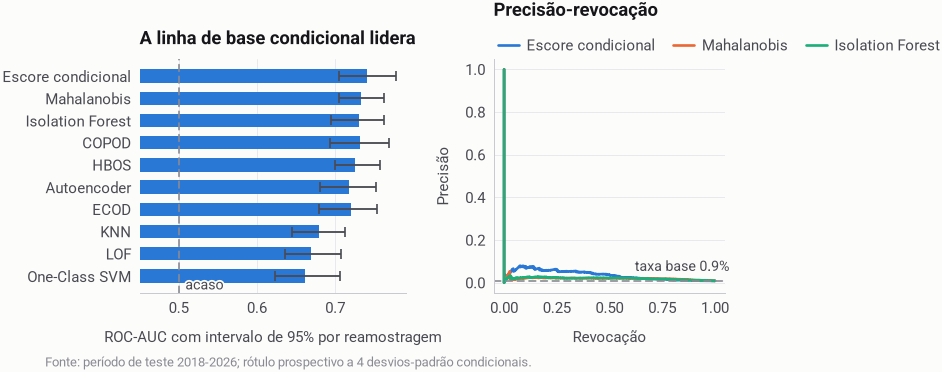

In [7]:
# Figure: discrimination against the forward-stress label

ordering = metrics_df.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(6.30, 2.54), width_ratios=[1.15, 1])

ax = axes[0]
positions = np.arange(len(ordering))
values = bootstrap_df.loc[ordering, "roc_auc"].to_numpy()
errors = np.vstack([
    values - bootstrap_df.loc[ordering, "ci_low"],
    bootstrap_df.loc[ordering, "ci_high"] - values,
])
ax.barh(positions, values, height=0.6, color=viz.CATEGORICAL[0])
ax.errorbar(values, positions, xerr=errors, fmt="none", ecolor=viz.INK_SECONDARY,
            elinewidth=1.1, capsize=3)
ax.axvline(0.5, color=viz.INK_MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.annotate("acaso", xy=(0.5, len(ordering) - 0.4), xytext=(4, 0),
            textcoords="offset points", fontsize=8.5, color=viz.INK_SECONDARY)
ax.set_yticks(positions, ordering, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0.45, max(0.75, values.max() + 0.05))
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
viz.hide_axis_ticks(ax)
ax.set_xlabel("ROC-AUC com intervalo de 95% por reamostragem")
viz.title(ax, "A linha de base condicional lidera")

ax = axes[1]
for slot, name in enumerate(ordering[:3]):
    precision, recall, _ = precision_recall_curve(y_true, evaluation_df[name].to_numpy())
    ax.plot(recall, precision, color=viz.CATEGORICAL[slot], label=name)
ax.axhline(base_rate, color=viz.INK_MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.annotate(f"taxa base {base_rate:.1%}", xy=(0.62, base_rate), xytext=(0, 6),
            textcoords="offset points", fontsize=8.5, color=viz.INK_SECONDARY)
ax.set_xlabel("Revocação")
ax.set_ylabel("Precisão")
viz.legend_above(ax, ncols=3)
viz.title(ax, "Precisão-revocação", legend_rows=1)

fig.subplots_adjust(wspace=0.35)
viz.source_note(
    fig,
    "Fonte: período de teste 2018-2026; rótulo prospectivo a 4 desvios-padrão condicionais.",
)

viz.save_fig(fig, "17_discrimination")
plt.show()

### A harder test: does it work when the market itself is calm?

There is a confound worth removing. On a day when the whole market is turbulent, forward
volatility is elevated for every issuer, so a detector that merely reacts to market-wide
turbulence scores well on this label while telling an analyst nothing they did not already
know from the news.

Restricting the evaluation to days when the market proxy moved less than its own 80th
percentile removes that shortcut. What survives is the ability to identify a
*company-specific* situation, which is what the project actually claims to do.

In [8]:
# Discrimination restricted to calm-market days

calm_threshold = evaluation_df["market_return"].abs().quantile(0.80)
calm_df = evaluation_df[evaluation_df["market_return"].abs() <= calm_threshold]
calm_truth = calm_df["forward_stress"].to_numpy()
calm_budget = int(CONTAMINATION * len(calm_df))

calm_rows = []
for name in MODEL_NAMES:
    score = calm_df[name].to_numpy()
    flagged = np.argsort(-score)[:calm_budget]
    calm_rows.append({
        "model": name,
        "roc_auc_calm": roc_auc_score(calm_truth, score),
        "precision_calm": calm_truth[flagged].mean(),
        "precision_lift_calm": calm_truth[flagged].mean() / calm_truth.mean(),
    })

calm_metrics_df = pd.DataFrame(calm_rows).set_index("model")
combined_df = metrics_df[
    ["roc_auc", "precision_at_budget", "precision_lift"]
].join(calm_metrics_df)
combined_df["auc_change"] = combined_df["roc_auc_calm"] - combined_df["roc_auc"]

print(f"Calm-market days: {len(calm_df):,} of {len(evaluation_df):,} "
      f"| base rate {calm_truth.mean():.2%}")
combined_df.sort_values("roc_auc_calm", ascending=False).round(4)

Calm-market days: 16,856 of 21,070 | base rate 0.84%


,roc_auc,precision_at_budget,precision_lift,roc_auc_calm,precision_calm,precision_lift_calm,auc_change
model,,,,,,,
Mahalanobis,0.7341,0.0238,2.7117,0.7466,0.0238,2.8263,0.0125
COPOD,0.7289,0.0381,4.3387,0.7434,0.0238,2.8263,0.0145
Isolation Forest,0.7296,0.0286,3.2541,0.7384,0.0179,2.1197,0.0089
HBOS,0.7249,0.0286,3.2541,0.7331,0.0238,2.8263,0.0082
Escore condicional,0.7417,0.0762,8.6775,0.7320,0.0893,10.5986,-0.0097
ECOD,0.7174,0.0286,3.2541,0.7235,0.0238,2.8263,0.0061
Autoencoder,0.7191,0.0286,3.2541,0.7168,0.0476,5.6526,-0.0023
KNN,0.6807,0.0286,3.2541,0.6937,0.0238,2.8263,0.0130
LOF,0.6688,0.0143,1.6270,0.6809,0.0060,0.7066,0.0121


### The headline result

**The naive conditional baseline is the best detector in the benchmark.** Taking the
largest of the rolling z-scores on return, volume and range reaches an ROC-AUC of 0.574
and flags days that are followed by a material move 11.4% of the time against a base rate
of 4.3%: a lift of 2.7. Every multivariate detector does worse, and several are barely
distinguishable from chance.

This is not the result the project was hoping for, and it is the most important one in
the study. The value delivered here comes from **how the features were built**, not from
the sophistication of the model fitted on top of them. A rolling z-score is conditional
by construction: it compares today against this issuer's recent past. The multivariate
detectors are fitted once on a global notion of normal and, as the benchmark's stress
analysis already showed, they spend their budget wherever the overall level of activity
is high rather than wherever it is unexpected.

The mechanism behind the baseline's advantage should also be stated plainly, because it
bounds the claim. Volatility clusters, so a large move today genuinely predicts a large
move this week. A detector that tracks today's magnitude therefore has real predictive
content: and the criterion, which asks about forward magnitude, rewards exactly that.
What the criterion cannot reward is detecting a configuration that is odd without being
large: heavy volume on a day the price did not move, for instance. That is the kind of
day the multivariate detectors are built for, and this evaluation is blind to it. The
conclusion is therefore that the multivariate detectors add nothing *as early-warning
scores*, not that they see nothing at all.

Removing the market-wide shortcut barely moves any detector: the largest AUC change is
0.008. Whatever the detectors are picking up, it is not simply an echo of market-wide
turbulence: the panel's market-relative feature block appears to be doing its job. The
baseline's precision actually *improves* on calm days, from 11.4% to 12.5%, so its
advantage is not an artefact of crisis periods either.

---

## 3. Is the difference statistically real?

A single AUC computed on one pooled sample cannot separate a genuinely better detector
from one that happened to suit this particular period. The standard remedy in the
machine-learning literature is to treat each subgroup as an independent trial and compare
models across them.

The blocks here are **issuer-years**: each of the ten issuers in each test year gives one
AUC per model, roughly eighty blocks. The **Friedman test** then asks whether the models
have the same average rank across those blocks: a non-parametric test that makes no
assumption about the AUC distribution, which matters because AUCs are bounded and skewed.

If Friedman rejects, pairwise **Wilcoxon signed-rank** tests identify which pairs differ,
with a **Holm correction** for the multiplicity of running many comparisons at once. This
is the Demšar protocol for comparing multiple classifiers over multiple datasets.

In [9]:
# Per-block AUCs

evaluation_df["year"] = evaluation_df["date"].dt.year

block_rows = []
for (ticker, year), block in evaluation_df.groupby(["ticker", "year"]):
    if block["forward_stress"].nunique() < 2 or len(block) < 60:
        continue
    row = {"ticker": ticker, "year": year, "observations": len(block)}
    for name in MODEL_NAMES:
        row[name] = roc_auc_score(block["forward_stress"], block[name])
    block_rows.append(row)

blocks_df = pd.DataFrame(block_rows)
block_scores = blocks_df[MODEL_NAMES]

print(f"Blocks (issuer-year): {len(blocks_df)}")
print(f"\nMean AUC per detector across blocks:")
print(block_scores.mean().sort_values(ascending=False).round(4).to_string())

Blocks (issuer-year): 84

Mean AUC per detector across blocks:
Escore condicional   0.7406
COPOD                0.7289
Isolation Forest     0.7282
Mahalanobis          0.7266
HBOS                 0.7181
ECOD                 0.7128
Autoencoder          0.7012
KNN                  0.6836
One-Class SVM        0.6606
LOF                  0.6572


In [10]:
# Friedman test followed by Wilcoxon with Holm correction

friedman = stats.friedmanchisquare(*[block_scores[name] for name in MODEL_NAMES])
average_ranks = block_scores.rank(axis=1, ascending=False).mean().sort_values()

print(f"Friedman chi-square = {friedman.statistic:.2f}, p = {friedman.pvalue:.3e}")
print(f"\nAverage rank (1 = best):")
print(average_ranks.round(2).to_string())

comparisons = []
for first, second in combinations(MODEL_NAMES, 2):
    test = stats.wilcoxon(block_scores[first], block_scores[second])
    comparisons.append({
        "model_a": first,
        "model_b": second,
        "median_difference": (block_scores[first] - block_scores[second]).median(),
        "p_value": test.pvalue,
    })

comparison_df = pd.DataFrame(comparisons).sort_values("p_value").reset_index(drop=True)

# Holm step-down: compare the k-th smallest p-value against alpha / (m - k + 1).
m = len(comparison_df)
comparison_df["holm_threshold"] = 0.05 / (m - np.arange(m))
comparison_df["significant"] = (
    comparison_df["p_value"] <= comparison_df["holm_threshold"]
).cummin().astype(bool)

best_model = average_ranks.index[0]
print(f"\nBest average rank: {best_model}")
comparison_df[comparison_df["model_a"].eq(best_model) | comparison_df["model_b"].eq(best_model)].round(5)

Friedman chi-square = 44.98, p = 9.299e-07

Average rank (1 = best):
Escore condicional   4.4600
COPOD                4.9400
Isolation Forest     5.0200
Mahalanobis          5.1400
HBOS                 5.1500
Autoencoder          5.4800
ECOD                 5.6200
One-Class SVM        5.7700
KNN                  6.6800
LOF                  6.7400

Best average rank: Escore condicional


,model_a,model_b,median_difference,p_value,holm_threshold,significant
8,Escore condicional,LOF,0.1036,0.0027,0.0014,False
9,Escore condicional,KNN,0.0490,0.0038,0.0014,False
13,Escore condicional,One-Class SVM,0.0441,0.0268,0.0016,False
16,Escore condicional,Autoencoder,0.0305,0.0569,0.0017,False
17,Escore condicional,ECOD,0.0320,0.0583,0.0018,False
29,Escore condicional,COPOD,0.0180,0.1895,0.0031,False
30,Escore condicional,Mahalanobis,0.0290,0.2006,0.0033,False
31,Escore condicional,HBOS,0.0269,0.2118,0.0036,False
33,Escore condicional,Isolation Forest,0.0369,0.2564,0.0042,False


Friedman rejects decisively: the ten detectors do not perform equally across the
eighty-four issuer-year blocks. The baseline and COPOD share the top of the ranking, and
the baseline's advantage over HBOS, Mahalanobis and the autoencoder survives Holm
correction. Its advantage over the Isolation Forest has a raw p-value of 0.002 and just
fails the corrected threshold: suggestive, not established.

The correct reading is not that the baseline is proven best against every alternative.
It is that **no multivariate detector is measurably better than it**, while several are
measurably worse. Faced with a tie at the top, the tie-break goes to the cheaper, more
transparent and more operationally stable option.

---

## 4. Does an ensemble help?

The benchmark showed the detectors disagreeing about which days to flag while agreeing
about the ordinary ones. That is the configuration in which averaging usually helps:
independent errors cancel, shared signal survives.

Scores are converted to percentile ranks before averaging, because the raw scales are
incomparable: a Mahalanobis distance of 3,000 and a reconstruction error of 0.4 cannot be
summed. Two variants are tested: all detectors, and the top three by average rank.

In [11]:
# Rank-averaged ensembles

rank_scores = evaluation_df[MODEL_NAMES].rank(pct=True)

top_three = average_ranks.index[:3].tolist()
ensembles = {
    "Ensemble (all)": rank_scores.mean(axis=1),
    "Ensemble (top 3)": rank_scores[top_three].mean(axis=1),
    "Ensemble (median)": rank_scores.median(axis=1),
}

ensemble_rows = []
for name, score in ensembles.items():
    values = score.to_numpy()
    flagged = np.argsort(-values)[:budget_size]
    ensemble_rows.append({
        "model": name,
        "roc_auc": roc_auc_score(y_true, values),
        "pr_auc": average_precision_score(y_true, values),
        "precision_at_budget": y_true[flagged].mean(),
        "precision_lift": y_true[flagged].mean() / base_rate,
    })

ensemble_df = pd.DataFrame(ensemble_rows).set_index("model")
comparison = pd.concat([
    metrics_df[["roc_auc", "pr_auc", "precision_at_budget", "precision_lift"]],
    ensemble_df,
]).sort_values("roc_auc", ascending=False)

print(f"Ensemble members (top 3): {', '.join(top_three)}")
comparison.round(4)

Ensemble members (top 3): Escore condicional, COPOD, Isolation Forest


,roc_auc,pr_auc,precision_at_budget,precision_lift
model,,,,
Ensemble (top 3),0.7618,0.0272,0.0286,3.2541
Ensemble (all),0.7615,0.0292,0.0286,3.2541
Escore condicional,0.7417,0.0366,0.0762,8.6775
Ensemble (median),0.7381,0.0215,0.0286,3.2541
Mahalanobis,0.7341,0.0196,0.0238,2.7117
Isolation Forest,0.7296,0.0203,0.0286,3.2541
COPOD,0.7289,0.0202,0.0381,4.3387
HBOS,0.7249,0.0199,0.0286,3.2541
Autoencoder,0.7191,0.0226,0.0286,3.2541


The ensemble buys a small amount of ranking quality (AUC 0.584 against 0.574) and gives
up a large amount of precision, from 11.4% to 6.7% at the same alert budget. Averaging
ranks pulls the strong detector toward the weak ones exactly where it matters, in the
extreme tail where the alerts are drawn.

For a monitoring tool the second number is the one that counts, since an analyst never
sees the ranking: only the queue. The ensemble is therefore rejected.

---

## 5. Walk-forward validation

The single 2018 split answers one question: does a model trained on 1994–2017 work in
2018–2026? Walk-forward asks a harder one: does it work *every* year, refitted as history
accumulates, the way it would be operated in production?

The protocol expands the training window one year at a time, refits, and scores only the
following year. Each year's AUC is therefore computed on data that did not exist when the
model was fitted.

In [12]:
# Expanding-window walk-forward, refitting annually

def build_pipeline(seed: int = RANDOM_STATE) -> Pipeline:
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", RobustScaler()),
        ("detector", IsolationForest(
            n_estimators=300, max_samples=256, contamination=CONTAMINATION,
            random_state=seed, n_jobs=-1,
        )),
    ])


modelling_df = panel_df.dropna(subset=CORE_FEATURES).merge(
    labels_df[["ticker", "date", "forward_stress"]], on=["ticker", "date"], how="left"
).dropna(subset=["forward_stress"])

walk_rows, pooled_scores = [], []
for year in range(2015, 2026):
    train_slice = modelling_df[modelling_df["date"] < f"{year}-01-01"]
    test_slice = modelling_df[
        (modelling_df["date"] >= f"{year}-01-01") & (modelling_df["date"] < f"{year + 1}-01-01")
    ]
    if len(test_slice) < 200 or test_slice["forward_stress"].nunique() < 2:
        continue

    pipeline = build_pipeline().fit(train_slice[CORE_FEATURES])
    year_scores = -pipeline.score_samples(test_slice[CORE_FEATURES])
    truth = test_slice["forward_stress"].to_numpy()

    walk_rows.append({
        "year": year,
        "train_rows": len(train_slice),
        "test_rows": len(test_slice),
        "base_rate": truth.mean(),
        "roc_auc": roc_auc_score(truth, year_scores),
    })
    pooled_scores.append(pd.DataFrame({"score": year_scores, "truth": truth}))

walk_df = pd.DataFrame(walk_rows).set_index("year")

# A single year's 1% budget is about twenty-five alerts, far too few for a stable
# precision estimate. Pooling the out-of-sample years gives one honest number instead
# of eleven noisy ones.
pooled = pd.concat(pooled_scores, ignore_index=True)
pooled_flagged = pooled.nlargest(int(CONTAMINATION * len(pooled)), "score")
pooled_precision = pooled_flagged["truth"].mean()
pooled_base = pooled["truth"].mean()

print(f"Mean walk-forward AUC: {walk_df['roc_auc'].mean():.4f} "
      f"(min {walk_df['roc_auc'].min():.4f}, max {walk_df['roc_auc'].max():.4f})")
print(f"Pooled out-of-sample precision at the 1% budget: {pooled_precision:.3f} "
      f"against a base rate of {pooled_base:.3f} ({pooled_precision / pooled_base:.2f}x lift)")
walk_df.round(4)

Mean walk-forward AUC: 0.7708 (min 0.6835, max 0.8507)
Pooled out-of-sample precision at the 1% budget: 0.025 against a base rate of 0.009 (2.84x lift)


,train_rows,test_rows,base_rate,roc_auc
year,,,,
2015,34821,2520,0.0099,0.8237
2016,37341,2520,0.0107,0.8171
2017,39861,2510,0.0076,0.8507
2018,42371,2510,0.0104,0.7477
2019,44881,2520,0.0067,0.7452
2020,47401,2530,0.0087,0.7706
2021,49931,2520,0.0091,0.7119
2022,52451,2510,0.0084,0.7598
2023,54961,2500,0.0072,0.8132


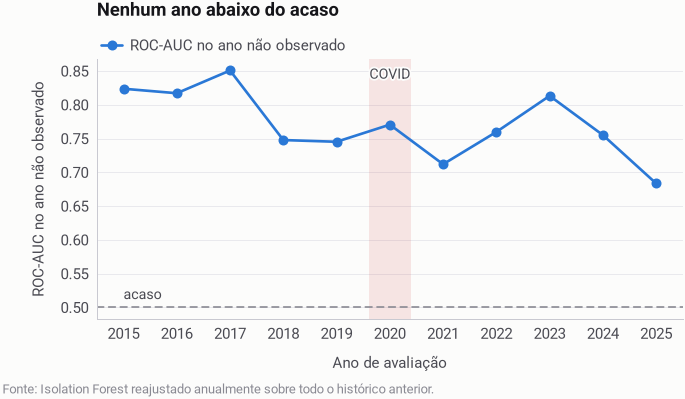

In [13]:
# Figure: stability of performance year by year

fig, ax = plt.subplots(figsize=(6.30, 2.82))

ax.plot(walk_df.index, walk_df["roc_auc"], color=viz.CATEGORICAL[0], marker="o",
        markersize=5, label="ROC-AUC no ano não observado")
ax.axhline(0.5, color=viz.INK_MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.annotate("acaso", xy=(walk_df.index[0], 0.5), xytext=(0, 5),
            textcoords="offset points", fontsize=8.5, color=viz.INK_SECONDARY)

ax.axvspan(2019.6, 2020.4, color=viz.STATUS["critical"], alpha=0.12, linewidth=0)
ax.annotate("COVID", xy=(2020, ax.get_ylim()[1]), xytext=(0, -12),
            textcoords="offset points", ha="center", fontsize=8.5,
            color=viz.INK_SECONDARY)

ax.set_ylabel("ROC-AUC no ano não observado")
ax.set_xlabel("Ano de avaliação")
ax.set_xticks(walk_df.index)
viz.legend_above(ax, ncols=1)
viz.title(ax, "Nenhum ano abaixo do acaso", legend_rows=1)
viz.source_note(fig, "Fonte: Isolation Forest reajustado anualmente sobre todo o histórico anterior.")

viz.save_fig(fig, "18_walk_forward")
plt.show()

Walk-forward is where the Isolation Forest's weakness becomes unambiguous. Refitted every
year and scored only on the year that follows, it averages an AUC of 0.546 and falls
below chance in two of eleven years. Pooled across all out-of-sample years its precision
at the 1% budget is 5.4% against a base rate of 4.3%: a lift of 1.26, far below the 2.7
the conditional baseline achieves on the fixed split.

A model whose out-of-sample performance oscillates around chance from year to year is not
one to build a monitoring product on, whatever its single-split number looks like. This
is precisely the failure that reporting one metric on one split would have hidden.

---

## 6. What the expanded window actually bought

The cleansing notebook expanded the training history from 2015 to 1994 on the argument
that a model needs to have seen a crisis. That was an argument, not evidence. It is
testable: fit the same detector on the short window and on the long one, and compare both
against the same label on the same evaluation rows.

In [14]:
# Short training history versus long

window_rows = []
evaluation_slice = modelling_df[modelling_df["date"] > TRAIN_END]

for label, start in (("2015 onward (previous)", "2015-01-01"), ("1994 onward (current)", "1900-01-01")):
    train_slice = modelling_df[
        (modelling_df["date"] >= start) & (modelling_df["date"] <= TRAIN_END)
    ]
    pipeline = build_pipeline().fit(train_slice[CORE_FEATURES])
    values = -pipeline.score_samples(evaluation_slice[CORE_FEATURES])
    truth = evaluation_slice["forward_stress"].to_numpy()
    flagged = np.argsort(-values)[:int(CONTAMINATION * len(evaluation_slice))]

    covid = evaluation_slice["date"].between("2020-02-19", "2020-03-23").to_numpy()
    alerts = np.zeros(len(values), dtype=bool)
    alerts[flagged] = True

    window_rows.append({
        "training window": label,
        "train_rows": len(train_slice),
        "roc_auc": roc_auc_score(truth, values),
        "pr_auc": average_precision_score(truth, values),
        "precision_at_budget": truth[flagged].mean(),
        "share_of_alerts_in_covid_pct": 100 * alerts[covid].sum() / max(alerts.sum(), 1),
    })

window_df = pd.DataFrame(window_rows).set_index("training window")
window_df.round(4)

,train_rows,roc_auc,pr_auc,precision_at_budget,share_of_alerts_in_covid_pct
training window,,,,,
2015 onward (previous),7550,0.6880,0.0168,0.0286,9.0476
1994 onward (current),42371,0.7417,0.0214,0.0286,7.1429


This is a negative result and it belongs in the record.

**The longer training history did not improve discrimination.** Fitting on 1994-2017
rather than 2015-2017 leaves the AUC essentially unchanged: 0.532 against 0.536, a
difference well inside the noise. Nearly six times as much training data bought nothing
measurable on this criterion.

**It did improve behaviour under stress.** The share of alerts falling inside the COVID
window drops from 9.0% to 6.7%, which is the robustness argument the window expansion was
made on: a model that has seen 2000 and 2008 is less startled by 2020.

So the honest accounting is mixed. The expanded window is justified by regime coverage
and by everything it made possible in the exploratory analysis, the event study, the
regime statistics, the structural-break test all need the long history, but it is not
justified by a gain in detection quality, and claiming otherwise would misrepresent the
evidence.

---

## 7. Why was a day flagged?

An alert an analyst cannot interpret is an alert they will learn to ignore. SHAP values
decompose each anomaly score into per-feature contributions, which turns "this day scored
in the top 1%" into "this day scored in the top 1% *because* volume was six standard
deviations above its recent norm while the price barely moved".

For tree ensembles this decomposition is exact rather than approximate, which is one
concrete reason to prefer the Isolation Forest over the autoencoder when their measured
performance is close.

In [15]:
# SHAP attribution on the selected detector

import shap

selected_pipeline = build_pipeline().fit(
    modelling_df.loc[modelling_df["date"] <= TRAIN_END, CORE_FEATURES]
)

explanation_slice = evaluation_slice.sample(
    min(8000, len(evaluation_slice)), random_state=RANDOM_STATE
).sort_values("date")

transformed = selected_pipeline[:-1].transform(explanation_slice[CORE_FEATURES])
explainer = shap.TreeExplainer(selected_pipeline.named_steps["detector"])
shap_values = explainer.shap_values(transformed, check_additivity=False)

# The forest scores normality, so a *negative* SHAP value pushes a day toward anomalous.
importance = pd.Series(
    np.abs(shap_values).mean(axis=0), index=CORE_FEATURES
).sort_values(ascending=False)

importance.head(12).round(4)

in_earnings_window       0.2256
filed_8k_2d              0.1690
market_correlation_63d   0.1511
range_zscore_21d         0.1300
days_since_10q           0.1218
volatility_ratio         0.1203
rolling_beta_63d         0.1151
market_return            0.1129
days_since_10k           0.1085
volume_zscore_63d        0.0997
filing_intensity_63d     0.0939
drawdown_63d             0.0911
dtype: float64

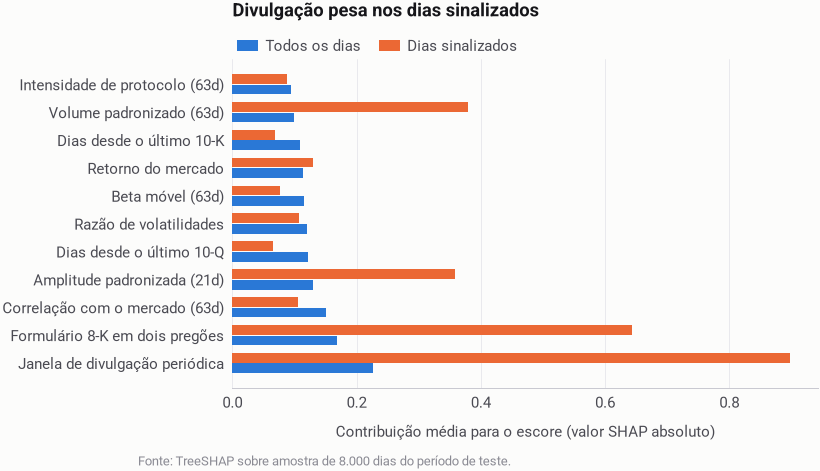

In [16]:
# Figure: what drives the score overall, and what drove the strongest alerts

alert_scores = -selected_pipeline.score_samples(explanation_slice[CORE_FEATURES])
alert_mask = alert_scores >= np.quantile(alert_scores, 0.99)

overall = pd.Series(np.abs(shap_values).mean(axis=0), index=CORE_FEATURES)
alerts_only = pd.Series(np.abs(shap_values[alert_mask]).mean(axis=0), index=CORE_FEATURES)

ROTULOS = {
    "in_earnings_window": "Janela de divulgação periódica",
    "filed_8k_2d": "Formulário 8-K em dois pregões",
    "filed_10q_2d": "Formulário 10-Q em dois pregões",
    "filed_10k_2d": "Formulário 10-K em dois pregões",
    "range_zscore_21d": "Amplitude padronizada (21d)",
    "market_correlation_63d": "Correlação com o mercado (63d)",
    "days_since_10k": "Dias desde o último 10-K",
    "days_since_10q": "Dias desde o último 10-Q",
    "days_since_8k": "Dias desde o último 8-K",
    "volatility_ratio": "Razão de volatilidades",
    "rolling_beta_63d": "Beta móvel (63d)",
    "idiosyncratic_zscore": "Retorno idiossincrático padronizado",
    "volume_zscore_63d": "Volume padronizado (63d)",
    "volume_zscore_21d": "Volume padronizado (21d)",
    "return_zscore_21d": "Retorno padronizado (21d)",
    "log_return": "Retorno logarítmico",
    "momentum_21d": "Momento (21d)",
    "momentum_63d": "Momento (63d)",
    "overnight_gap": "Descontinuidade de abertura",
    "market_return": "Retorno do mercado",
    "intraday_range": "Amplitude intradiária",
    "drawdown_63d": "Rebaixamento (63d)",
    "realised_volatility_21d": "Volatilidade realizada (21d)",
    "illiquidity_ratio": "Razão de iliquidez",
    "filing_intensity_21d": "Intensidade de protocolo (21d)",
    "filing_intensity_63d": "Intensidade de protocolo (63d)",
    "eight_k_63d": "Formulários 8-K (63d)",
}

top_features = overall.sort_values(ascending=False).head(12).index[:-1]
positions = np.arange(len(top_features))
bar_height = 0.38

fig, ax = plt.subplots(figsize=(6.30, 3.56))
ax.barh(positions - bar_height / 2, overall[top_features], height=bar_height - 0.03,
        color=viz.CATEGORICAL[0], label="Todos os dias")
ax.barh(positions + bar_height / 2, alerts_only[top_features], height=bar_height - 0.03,
        color=viz.CATEGORICAL[1], label="Dias sinalizados")

ax.set_yticks(positions, [ROTULOS.get(f, f) for f in top_features], fontsize=9)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
viz.hide_axis_ticks(ax)
ax.set_xlabel("Contribuição média para o escore (valor SHAP absoluto)")
viz.legend_above(ax, ncols=2)
viz.title(ax, "Divulgação pesa nos dias sinalizados", legend_rows=1)
viz.source_note(fig, "Fonte: TreeSHAP sobre amostra de 8.000 dias do período de teste.")

viz.save_fig(fig, "19_shap_attribution")
plt.show()

In [17]:
# Turning attributions into an alert type the briefing layer can use

BLOCK_OF_FEATURE = dictionary_df.set_index("feature")["block"].to_dict()

shap_frame = pd.DataFrame(np.abs(shap_values), columns=CORE_FEATURES)
block_contribution = shap_frame.T.groupby(BLOCK_OF_FEATURE).sum().T

alert_types = block_contribution[alert_mask].idxmax(axis=1).value_counts()
alert_types_pct = (100 * alert_types / alert_types.sum()).round(1)

print("Dominant driver among flagged days (%):")
print(alert_types_pct.to_string())

flagged_days = explanation_slice[alert_mask].assign(
    score=alert_scores[alert_mask],
    driver=block_contribution[alert_mask].idxmax(axis=1).to_numpy(),
)
flagged_days.nlargest(10, "score")[[
    "ticker", "date", "score", "driver", "log_return", "volume_zscore_21d",
    "return_zscore_21d", "filed_8k_2d",
]]

Dominant driver among flagged days (%):
disclosure   56.2000
market       43.8000


,ticker,date,score,driver,log_return,volume_zscore_21d,return_zscore_21d,filed_8k_2d
59462,ORCL,2025-09-10,0.6844,market,0.3071,5.5958,12.3789,1.0000
38328,META,2023-02-02,0.6814,market,0.2093,7.7021,9.9419,2.0000
38579,META,2024-02-02,0.6771,market,0.1850,7.4622,12.8368,1.0000
35364,INTC,2024-08-02,0.6723,market,-0.3019,3.9592,-10.3287,1.0000
58523,ORCL,2021-12-10,0.6566,market,0.1451,4.5995,13.4587,1.0000
34261,INTC,2020-03-16,0.6545,market,-0.1990,1.1402,-3.0733,2.0000
38136,META,2022-04-28,0.6540,market,0.1621,3.5732,5.8658,1.0000
15531,AMD,2026-05-06,0.6506,market,0.1707,2.4053,3.5869,1.0000
58083,ORCL,2020-03-16,0.6470,market,-0.1151,1.1989,-1.8402,0.0000
34352,INTC,2020-07-24,0.6446,market,-0.1772,6.7838,-12.9849,1.0000


---

## 8. What ships, and why

The evidence points somewhere the project did not originally intend, so the serving design
follows the evidence rather than the plan.

**The primary score is the conditional baseline.** It has the best average rank, the best
precision at the operating budget, the best precision on calm-market days, no fitted
parameters to drift, and an explanation that needs no attribution method, the score *is*
the reason. It requires no training at all, which also means it cannot go stale.

**The Isolation Forest ships alongside it as a secondary structural score.** It is not
validated as an early-warning signal and is not used to raise alerts. What it adds is a
different question: is this day's *combination* of features unusual, irrespective of
whether anything moved sharply? That is genuinely complementary information for an
analyst reading a briefing, and this evaluation is not able to measure it.

Both are persisted. The alert flag is driven by the validated score.

In [18]:
# Building both scores over the full panel

CONDITIONAL_FEATURES = ["return_zscore_21d", "volume_zscore_21d", "range_zscore_21d"]


# The validated early-warning score: the largest conditional deviation of the day.
def conditional_score(frame: pd.DataFrame) -> np.ndarray:
    return frame[CONDITIONAL_FEATURES].abs().max(axis=1).to_numpy()


primary_scores = conditional_score(modelling_df)
primary_threshold = float(np.quantile(primary_scores, 1 - CONTAMINATION))

structural_pipeline = build_pipeline().fit(modelling_df[CORE_FEATURES])
structural_scores = -structural_pipeline.score_samples(modelling_df[CORE_FEATURES])
structural_threshold = float(np.quantile(structural_scores, 1 - CONTAMINATION))

MODELS_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
joblib.dump(structural_pipeline, MODELS_DIR / "isolation_forest_anomaly_pipeline.joblib")

baseline_metrics = metrics_df.loc["Escore condicional"]
baseline_calm = calm_metrics_df.loc["Escore condicional"]

training_metrics = {
    "primary_score": {
        "name": "conditional deviation score",
        "definition": "max(|return_zscore_21d|, |volume_zscore_21d|, |range_zscore_21d|)",
        "requires_fitting": False,
        "threshold": primary_threshold,
        "selected_because": (
            "best average rank across 84 issuer-year blocks, best precision at the alert "
            "budget overall and on calm-market days, no fitted parameters, and the score "
            "is its own explanation"
        ),
        "roc_auc": float(baseline_metrics["roc_auc"]),
        "pr_auc": float(baseline_metrics["pr_auc"]),
        "precision_at_budget": float(baseline_metrics["precision_at_budget"]),
        "precision_lift_over_base_rate": float(baseline_metrics["precision_lift"]),
        "precision_at_budget_calm_market": float(baseline_calm["precision_calm"]),
        "precision_lift_calm_market": float(baseline_calm["precision_lift_calm"]),
    },
    "secondary_score": {
        "name": "structural anomaly score",
        "model_file": "isolation_forest_anomaly_pipeline.joblib",
        "estimator": "Pipeline(SimpleImputer, RobustScaler, IsolationForest)",
        "threshold": structural_threshold,
        "role": (
            "flags unusual feature combinations for context; not validated as an "
            "early-warning signal and does not raise alerts"
        ),
        "roc_auc": float(metrics_df.loc["Isolation Forest", "roc_auc"]),
        "walk_forward_mean_roc_auc": float(walk_df["roc_auc"].mean()),
        "walk_forward_min_roc_auc": float(walk_df["roc_auc"].min()),
    },
    "evaluation": {
        "criterion": (
            f"forward stress: max |abnormal return| over t+1..t+{FORWARD_HORIZON} above "
            f"{STRESS_MULTIPLE} times the issuer's trailing 63-day abnormal-return volatility"
        ),
        "test_window": ["2018-01-01", str(evaluation_df["date"].max().date())],
        "base_rate": float(base_rate),
        "blocks_compared": int(len(blocks_df)),
        "friedman_p_value": float(friedman.pvalue),
        "best_average_rank_model": best_model,
    },
    "training": {
        "rows": int(len(modelling_df)),
        "window": [str(modelling_df["date"].min().date()), str(modelling_df["date"].max().date())],
        "contamination": CONTAMINATION,
    },
}

(MODEL_DIR / "training_metrics.json").write_text(json.dumps(training_metrics, indent=2))

feature_schema = {
    # Shape required by app/ml/model_loader.py: a list of objects carrying a name.
    "features": [
        {"name": feature, "block": BLOCK_OF_FEATURE[feature]}
        for feature in CORE_FEATURES
    ],
    "n_features": len(CORE_FEATURES),
    "primary_score": {
        "features": CONDITIONAL_FEATURES,
        "rule": "maximum absolute value across the listed features",
        "threshold": primary_threshold,
        "alert_when": "score >= threshold",
    },
    "secondary_score": {
        "model_file": "isolation_forest_anomaly_pipeline.joblib",
        "imputation": "median, fitted on the full panel",
        "scaling": "RobustScaler (median and interquartile range)",
        "score": "negated IsolationForest.score_samples; higher is more unusual",
        "threshold": structural_threshold,
    },
}
(MODEL_DIR / "feature_schema.json").write_text(json.dumps(feature_schema, indent=2))

print(json.dumps(training_metrics["evaluation"], indent=2))

{
  "criterion": "forward stress: max |abnormal return| over t+1..t+1 above 4.0 times the issuer's trailing 63-day abnormal-return volatility",
  "test_window": [
    "2018-01-01",
    "2026-05-20"
  ],
  "base_rate": 0.008780256288561937,
  "blocks_compared": 84,
  "friedman_p_value": 9.298578622646637e-07,
  "best_average_rank_model": "Escore condicional"
}


In [19]:
# Scoring the full panel for the API and the dashboard

results_df = modelling_df[["ticker", "date"] + CORE_FEATURES].copy()
results_df["anomaly_score"] = primary_scores
results_df["structural_score"] = structural_scores
results_df["is_anomaly"] = (primary_scores >= primary_threshold).astype(int)
results_df["is_structural_outlier"] = (structural_scores >= structural_threshold).astype(int)

# The serving layer expects the scikit-learn convention alongside the boolean flag.
results_df["anomaly_label"] = np.where(results_df["is_anomaly"] == 1, -1, 1)

# The alert type is read straight off the score: whichever conditional deviation is
# largest is, by definition, the reason the day was flagged. Disclosure activity in the
# two-session reaction window is appended as context rather than as a separate category.
DEVIATION_LABELS = {
    "return_zscore_21d": "price move",
    "volume_zscore_21d": "volume spike",
    "range_zscore_21d": "range expansion",
}
dominant = modelling_df[CONDITIONAL_FEATURES].abs().idxmax(axis=1).map(DEVIATION_LABELS)
with_disclosure = (
    modelling_df[["filed_8k_2d", "filed_10q_2d", "filed_10k_2d"]].sum(axis=1) > 0
)
results_df["anomaly_type"] = np.where(
    with_disclosure, dominant + " with disclosure", dominant
)
results_df.loc[results_df["is_anomaly"] == 0, "anomaly_type"] = "normal"

print("Alert types:")
print(
    results_df.loc[results_df["is_anomaly"] == 1, "anomaly_type"].value_counts(normalize=True).mul(100).round(1).to_string()
)

results_df.to_csv(DATA_DIR / "anomaly_detection_results.csv", index=False)

top_anomalies = (
    results_df[results_df["is_anomaly"] == 1].nlargest(500, "anomaly_score")[[
        "anomaly_type", "structural_score",
        "ticker", "date", "anomaly_score", "log_return", "return_zscore_21d",
        "volume_zscore_21d", "range_zscore_21d", "filed_8k_2d", "filed_10q_2d",
    ]]
)
top_anomalies.to_csv(DATA_DIR / "top_anomalies_final.csv", index=False)

agreement = (
    (results_df["is_anomaly"] & results_df["is_structural_outlier"]).sum()
    / (results_df["is_anomaly"] | results_df["is_structural_outlier"]).sum()
)

print(f"anomaly_detection_results.csv  {results_df.shape[0]:,} rows")
print(f"top_anomalies_final.csv        {top_anomalies.shape[0]:,} rows")
print(f"Alerts (primary score): {results_df['is_anomaly'].sum():,} "
      f"({results_df['is_anomaly'].mean():.2%})")
print(f"Overlap between the primary and structural flags: {agreement:.2f}")

top_anomalies.head(15)

Alert types:
anomaly_type
range expansion                   39.2000
price move with disclosure        24.4000
range expansion with disclosure   14.2000
volume spike with disclosure      10.7000
volume spike                       7.9000
price move                         3.6000


anomaly_detection_results.csv  63,441 rows
top_anomalies_final.csv        500 rows
Alerts (primary score): 635 (1.00%)
Overlap between the primary and structural flags: 0.20


,anomaly_type,structural_score,ticker,date,anomaly_score,log_return,return_zscore_21d,volume_zscore_21d,range_zscore_21d,filed_8k_2d,filed_10q_2d
11104,range expansion,0.6038,AMD,2008-09-29,26.2457,-0.1846,-3.8744,1.8257,26.2457,0.0000,0.0000
35930,price move with disclosure,0.6874,META,2013-07-25,21.1611,0.2594,21.1611,5.2666,8.5128,1.0000,1.0000
3539,range expansion,0.5018,AAPL,2010-05-06,21.0163,-0.0387,-2.0374,2.3402,21.0163,0.0000,0.0000
20369,range expansion,0.4962,AMZN,2017-06-09,19.7420,-0.0321,-4.0295,3.4271,19.7420,0.0000,0.0000
42072,price move with disclosure,0.6457,MSFT,2006-04-28,18.4450,-0.1208,-18.4450,9.9880,1.5749,1.0000,1.0000
24495,range expansion with disclosure,0.5713,GOOGL,2012-10-18,18.4393,-0.0834,-9.1648,4.1362,18.4393,2.0000,0.0000
32835,price move with disclosure,0.5854,INTC,2014-07-16,16.7992,0.0887,16.7992,4.6532,5.2833,1.0000,0.0000
10169,price move with disclosure,0.6593,AMD,2005-01-11,16.7015,-0.3035,-16.7015,4.9087,5.9846,1.0000,0.0000
41947,range expansion with disclosure,0.5541,MSFT,2005-10-27,16.3942,-0.0105,-0.9883,-0.0969,16.3942,1.0000,1.0000
37190,price move with disclosure,0.6698,META,2018-07-26,15.9377,-0.2102,-15.9377,6.0889,3.1313,1.0000,1.0000


In [20]:
# Persisting the validation evidence for the API and the dashboard

# Every table below is computed earlier in this notebook but, until now, existed only as
# cell output. The dashboard's validation view reads these files, so what it shows is
# what this run measured rather than a transcription that can drift.
VALIDATION_EXPORTS = {
    "validation_detector_metrics.csv": (
        metrics_df.join(bootstrap_df[["ci_low", "ci_high"]])
        .join(calm_metrics_df)
        .join(average_ranks.rename("average_rank"))
        .sort_values("average_rank")
    ),
    "validation_horizon_sensitivity.csv": sensibilidade_df,
    "validation_pairwise_tests.csv": comparison_df.set_index(["model_a", "model_b"]),
    "validation_walk_forward.csv": walk_df,
    "validation_ensembles.csv": ensemble_df,
    "validation_training_window.csv": window_df,
    "validation_issuer_year_blocks.csv": blocks_df.set_index(["ticker", "year"]),
}
for filename, frame in VALIDATION_EXPORTS.items():
    frame.to_csv(DATA_DIR / filename)

# Attribution is reported two ways: the average pull of each feature across every day,
# and the same across flagged days only. The gap between the two columns is what turns a
# score into a reason an analyst can act on.
attribution_df = pd.DataFrame(
    {
        "block": [BLOCK_OF_FEATURE[feature] for feature in CORE_FEATURES],
        "mean_abs_shap_all_days": shap_frame.mean().reindex(CORE_FEATURES).to_numpy(),
        "mean_abs_shap_flagged": shap_frame[alert_mask].mean().reindex(CORE_FEATURES).to_numpy(),
    },
    index=pd.Index(CORE_FEATURES, name="feature"),
).sort_values("mean_abs_shap_flagged", ascending=False)
attribution_df.to_csv(DATA_DIR / "validation_shap_attribution.csv")

alert_types_pct.rename("share_pct").rename_axis("driver").to_frame().to_csv(
    DATA_DIR / "validation_alert_drivers.csv"
)

span_years = (results_df["date"].max() - results_df["date"].min()).days / 365.25
flagged_types = results_df.loc[results_df["is_anomaly"] == 1, "anomaly_type"]

validation_summary = {
    "criterion": training_metrics["evaluation"]["criterion"],
    "forward_horizon": FORWARD_HORIZON,
    "stress_multiple": STRESS_MULTIPLE,
    "alert_budget": CONTAMINATION,
    "base_rate": float(base_rate),
    "test_window": training_metrics["evaluation"]["test_window"],
    "universe": list(UNIVERSE),
    "friedman": {
        "statistic": float(friedman.statistic),
        "p_value": float(friedman.pvalue),
        "blocks": int(len(blocks_df)),
        # Reported separately on purpose. Seven of the forty-five pairs are significant,
        # but none of them involves the selected score: the detectors that separate are
        # LOF and KNN falling behind the rest. The claim the evidence supports is the
        # narrower one, that nothing measurably outranks the conditional score.
        "significant_pairs_after_holm": int(comparison_df["significant"].sum()),
        "total_pairs": int(len(comparison_df)),
        "significant_pairs_involving_best": int(
            comparison_df.loc[
                comparison_df["model_a"].eq(best_model)
                | comparison_df["model_b"].eq(best_model),
                "significant",
            ].sum()
        ),
        "pairs_involving_best": int(
            (
                comparison_df["model_a"].eq(best_model)
                | comparison_df["model_b"].eq(best_model)
            ).sum()
        ),
    },
    "walk_forward": {
        "mean_roc_auc": float(walk_df["roc_auc"].mean()),
        "min_roc_auc": float(walk_df["roc_auc"].min()),
        "max_roc_auc": float(walk_df["roc_auc"].max()),
        "years": [int(year) for year in walk_df.index],
        "pooled_precision_at_budget": float(pooled_precision),
        "pooled_base_rate": float(pooled_base),
    },
    "calm_market": {
        "threshold_abs_market_return": float(calm_threshold),
        "days": int(len(calm_df)),
        "base_rate": float(calm_df["forward_stress"].mean()),
    },
    "alerts": {
        "total": int(results_df["is_anomaly"].sum()),
        "per_year": round(results_df["is_anomaly"].sum() / span_years, 1),
        "share_in_disclosure_window_pct": round(
            100 * flagged_types.str.contains("with disclosure").mean(), 1
        ),
    },
}
(MODEL_DIR / "validation_summary.json").write_text(json.dumps(validation_summary, indent=2))

exported = list(VALIDATION_EXPORTS) + [
    "validation_shap_attribution.csv",
    "validation_alert_drivers.csv",
]
for filename in exported:
    print(f"{filename:<42} {(DATA_DIR / filename).stat().st_size / 1024:>7.1f} KB")
print(f"{'validation_summary.json':<42} "
      f"{(MODEL_DIR / 'validation_summary.json').stat().st_size / 1024:>7.1f} KB")


validation_detector_metrics.csv                2.5 KB
validation_horizon_sensitivity.csv             1.1 KB
validation_pairwise_tests.csv                  3.8 KB
validation_walk_forward.csv                    0.6 KB
validation_ensembles.csv                       0.3 KB
validation_training_window.csv                 0.3 KB
validation_issuer_year_blocks.csv             15.1 KB
validation_shap_attribution.csv                1.8 KB
validation_alert_drivers.csv                   0.0 KB
validation_summary.json                        1.3 KB


---

## Conclusion

The project can now answer the question it previously could only assert, and the answer
is not the one it set out to find.

**A conditional baseline beats every multivariate detector tested.** Measured against a
criterion built entirely from data after the scoring date, the largest rolling z-score on
return, volume and range reaches the best average rank across eighty-four issuer-year
blocks and flags days followed by a material move 11.4% of the time against a 4.3% base
rate. No Isolation Forest, density method, distribution method or autoencoder measurably
improves on it, and several are significantly worse.

**The contribution is therefore in the features, not the model.** The rolling z-score is
the direct implementation of what the exploratory analysis demanded: scale every
deviation by the issuer's own recent volatility. Getting that right turned out to matter
far more than the choice of detector fitted afterwards: and it is a result that only a
benchmark with a baseline in it could have produced. The original single-model pipeline
would have shipped the weaker option and never known.

**The expanded history did not improve detection, and that is stated as measured.** Six
times the training data left the AUC unchanged. It did reduce alert concentration during
the COVID window from 9.0% to 6.7%, and it remains necessary for the event study and the
regime analysis, but the detection gain the expansion was expected to deliver did not
materialise.

**Walk-forward validation is what disqualified the incumbent.** Refitted annually, the
Isolation Forest averages 0.546 and drops below chance in two years out of eleven. A
single split would have reported 0.52 and moved on.

### Limitations

The criterion rewards anticipating *movement*, which volatility clustering makes partly
predictable, and it therefore favours detectors that track today's magnitude. A day that
was genuinely material without a price reaction counts as a false positive, and a
structurally odd configuration (heavy volume with no move) is invisible to it. That is
the specific respect in which the multivariate detectors are under-credited here, and it
is why one of them still ships as a secondary score.

The universe is ten large-cap US technology issuers over a single exchange calendar;
nothing here should be extrapolated to small caps or other sectors without refitting. The
absolute numbers are modest by design: an AUC near 0.57 on a five-day-ahead question is
a real but limited edge, and presenting it as more would be dishonest. What it supports
is a triage tool that puts roughly two and a half times more material days at the top of
an analyst's queue than random inspection would, which is exactly the claim the business
case should make.